# Baseline Environment

## 1.Environment Check

In [7]:
#GPU检测
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("No GPU found")

CUDA available: True
GPU Name: Tesla T4


In [8]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
print(torch.version.cuda)

True
Tesla T4
12.8


In [9]:
import torch
import transformers
import platform

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0))
print("Transformers:", transformers.__version__)

Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA: 12.8
GPU: Tesla T4
Transformers: 5.0.0


In [10]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats() # 清空显存

## 2.Install Dependencies

In [11]:
# 安装 Experiment 001 所需的最小依赖
# transformers：加载 Gemma 模型与 tokenizer
# accelerate：辅助模型自动放置到 GPU
# sentencepiece：部分 tokenizer 需要
!pip install -q transformers accelerate sentencepiece huggingface_hub

## 3.Authentication

In [12]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))
print("✅ HF login success")

✅ HF login success


## 4.Load Model

In [13]:
# 导入必要库
# torch 用于控制 GPU 与推理精度
# AutoTokenizer / AutoModelForCausalLM 用于从 Hugging Face 加载模型
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# 先使用小模型，保证 T4 16GB 显存下能稳定跑通
# 如果这个模型需要 Hugging Face 授权，我们再处理登录
model_id = "google/gemma-2-2b-it"

# 加载 tokenizer：负责把文本转成 token，也负责把输出 token 解码回文本
tokenizer = AutoTokenizer.from_pretrained(model_id)

# 加载模型
# torch_dtype=torch.float16：使用 FP16 降低显存占用
# device_map="auto"：让 transformers/accelerate 自动把模型放到 GPU
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Model loaded:", model_id)
print("Device:", model.device)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

Model loaded: google/gemma-2-2b-it
Device: cuda:0


## 5.Baseline Profiling

In [16]:
import torch
import time
import gc

# ═══════════════════════════════════════════════════════════
# 工具函数区
# ═══════════════════════════════════════════════════════════

def get_gpu_memory_mb():
    """
    读取当前GPU已分配显存（MB）。

    注意：这是"已分配"而非"已使用"。PyTorch的显存分配器会提前
    申请一块显存池，所以这个数字反映的是PyTorch向GPU申请了多少，
    不是操作系统层面显示的显存占用。
    """
    return torch.cuda.memory_allocated() / 1024**2  # bytes → MB


def estimate_kv_cache_mb(model, seq_len, batch_size=1):
    """
    从模型结构参数出发，理论估算KV Cache的显存大小。

    KV Cache是什么：
        在autoregressive推理中，每次decode一个新token时，
        模型需要访问所有之前token的Key和Value矩阵。
        KV Cache就是把这些中间结果缓存下来，避免重复计算。

    公式推导：
        每个token在每一层会产生：
            - 1个Key向量：形状 = (num_kv_heads, head_dim)
            - 1个Value向量：形状 = (num_kv_heads, head_dim)

        整个序列的KV Cache大小 =
            2          （K和V各一份）
            × num_layers      （每层都有独立的KV）
            × num_kv_heads    （GQA/MQA模型的KV head数，可能小于Q head数）
            × head_dim        （每个head的维度）
            × seq_len         （已处理的token数量）
            × batch_size      （并发请求数）
            × bytes_per_elem  （float16 = 2字节）

    参数说明：
        model   : 已加载的HuggingFace模型
        seq_len : prefill长度 + 已生成token数（总序列长度）
        batch_size: 并行batch数，我们实验固定为1

    返回：
        估算的KV Cache大小（MB）

    局限性：
        这是理论下界。实际显存占用还包括：
        - PyTorch的显存碎片
        - 激活值（activations）
        - attention score矩阵（如果不用flash attention）
        所以实测peak_mem会高于这个估算值。
    """
    cfg = model.config

    # 总层数：Transformer的decoder层数（Gemma 2-2B = 26层）
    num_layers = cfg.num_hidden_layers

    # KV head数：现代模型常用GQA（分组查询注意力），KV head数 < Q head数
    # getattr的fallback处理：如果模型config没有num_key_value_heads字段，
    # 就退化为标准MHA（KV head数 = Q head数）
    num_kv_heads = getattr(cfg, 'num_key_value_heads', cfg.num_attention_heads)

    # 每个head的维度：Gemma系列有显式的head_dim字段；
    # 如果没有，用 hidden_size ÷ num_attention_heads 计算
    head_dim = cfg.head_dim if hasattr(cfg, 'head_dim') else cfg.hidden_size // cfg.num_attention_heads

    bytes_per_elem = 2  # float16精度，每个元素占2字节

    # 套公式
    total_bytes = (2 * num_layers * num_kv_heads * head_dim
                   * seq_len * batch_size * bytes_per_elem)

    return total_bytes / 1024**2  # bytes → MB


# ═══════════════════════════════════════════════════════════
# 核心测量函数
# ═══════════════════════════════════════════════════════════

def measure_single(prompt_len, gen_len, model, tokenizer, device):
    """
    对一组(prompt_len, gen_len)参数进行单次完整的性能测量。

    测量流程：
        1. 构造指定长度的输入prompt
        2. 跑一次完整的prefill，计时得到TTFT
        3. 逐token跑gen_len次decode，每次计时得到单步TPOT
        4. 读取峰值显存，估算KV Cache
        5. 清理显存，返回结果字典

    为什么prefill和decode要分开测量：
        - prefill是"并行处理整个输入序列"，计算密集，受限于GPU算力
        - decode是"逐token串行生成"，每步只处理1个token，受限于显存带宽
        这两个阶段的性能瓶颈不同，必须分开分析，这是LLM推理研究的核心问题。
    """

    # ── Step 1: 构造输入 ──────────────────────────────────
    # 用一个固定的英文句子重复填充，确保token分布稳定
    # prompt_len // 10 + 1 是为了保证重复次数足够多，能截断到目标长度
    base = "The quick brown fox jumps over the lazy dog. "
    prompt = base * (prompt_len // 10 + 1)

    # tokenizer负责把文本转成token id序列
    # truncation=True + max_length=prompt_len：截断到目标长度
    # return_tensors="pt"：返回PyTorch tensor
    # .to(device)：把tensor搬到GPU上
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=prompt_len
    ).to(device)

    # 记录实际token数（可能因分词边界略小于prompt_len）
    actual_prompt_len = inputs.input_ids.shape[1]

    # ── Step 2: 重置显存统计 ──────────────────────────────
    # synchronize()：等待GPU上所有异步操作完成，确保计时起点干净
    # reset_peak_memory_stats()：清零PyTorch的峰值显存记录器，
    #   这样后面读到的peak值只反映本次实验的最高点
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats()
    mem_before = get_gpu_memory_mb()  # 记录基准显存（当前已占用）

    # ── Step 3: Prefill阶段 → 测量TTFT ───────────────────
    # TTFT（Time To First Token）：从输入prompt到生成第一个token的延迟
    # 这个阶段模型并行处理所有输入token，是计算密集型操作
    #
    # use_cache=True：让模型保存KV Cache，供decode阶段复用
    # torch.no_grad()：推理阶段不需要计算梯度，节省显存和计算
    t0 = time.perf_counter()  # perf_counter比time.time()精度更高
    with torch.no_grad():
        outputs = model(input_ids=inputs.input_ids, use_cache=True)
    torch.cuda.synchronize()  # 必须sync，否则GPU还没跑完就记时了
    ttft = (time.perf_counter() - t0) * 1000  # 转换为毫秒

    # 从prefill输出中取出两个关键结果：
    # past_key_values：缓存好的KV矩阵，形状=(num_layers, 2, batch, heads, seq, dim)
    # next_token：prefill阶段预测的第一个输出token（取logits最大值的index）
    past_kv = outputs.past_key_values
    next_token = outputs.logits[:, -1, :].argmax(dim=-1, keepdim=True)
    # logits形状：(batch=1, seq_len, vocab_size)
    # [:, -1, :]取最后一个位置的预测；argmax取概率最大的token id
    # keepdim=True保持(1,1)的形状，作为下一步的输入

    # ── Step 4: Decode阶段 → 测量TPOT ────────────────────
    # TPOT（Time Per Output Token）：每生成一个新token的平均耗时
    # decode是串行的：每步输入1个token，利用KV Cache避免重算历史
    decode_times = []

    for _ in range(gen_len):
        t1 = time.perf_counter()
        with torch.no_grad():
            # 每次只输入最新生成的那1个token
            # past_key_values传入缓存，模型不需要重新处理历史token
            out = model(
                input_ids=next_token,
                past_key_values=past_kv,
                use_cache=True
            )
        torch.cuda.synchronize()
        decode_times.append((time.perf_counter() - t1) * 1000)

        # 更新KV Cache和下一个token（自回归：用刚生成的token预测下一个）
        past_kv = out.past_key_values
        next_token = out.logits[:, -1, :].argmax(dim=-1, keepdim=True)

    # ── Step 5: 汇总指标 ─────────────────────────────────
    tpot = sum(decode_times) / len(decode_times)  # 平均每token耗时(ms)
    tokens_s = 1000.0 / tpot                       # 吞吐率：tokens/秒

    # 峰值显存：本次实验从reset到现在的最高显存占用点
    peak_mem = torch.cuda.max_memory_allocated() / 1024**2

    # KV Cache理论估算：传入(prefill长度 + 已生成长度)作为总序列长度
    kv_est = estimate_kv_cache_mb(model, actual_prompt_len + gen_len)

    # ── Step 6: 清理显存 ─────────────────────────────────
    # KV Cache在显存里会持续占用，如果不手动清理，
    # 下一次实验的peak_mem读数会被上次的KV Cache污染
    del past_kv, outputs, out
    gc.collect()               # 触发Python垃圾回收
    torch.cuda.empty_cache()   # 把PyTorch缓存的显存还给GPU驱动

    return {
        "prompt_len":  actual_prompt_len,   # 实际prompt token数
        "gen_len":     gen_len,             # 生成token数
        "ttft_ms":     round(ttft, 2),      # 首token延迟(ms)
        "tpot_ms":     round(tpot, 2),      # 平均单token解码延迟(ms)
        "tokens_s":    round(tokens_s, 1),  # 解码吞吐率(tokens/s)
        "peak_mem_mb": round(peak_mem, 1),  # 峰值显存(MB)
        "kv_est_mb":   round(kv_est, 2),    # KV Cache估算大小(MB)
    }


# ═══════════════════════════════════════════════════════════
# 实验主循环：扫描(prompt_len × gen_len)参数矩阵
# ═══════════════════════════════════════════════════════════

results = []
device = next(model.parameters()).device

# 实验参数矩阵：
# prompt_lengths：控制prefill阶段的输入长度，观察TTFT随输入增长的趋势
# gen_lengths   ：控制decode阶段的生成长度，观察TPOT和显存的变化
# 共4×3=12组实验
prompt_lengths = [64, 128, 256, 512]
gen_lengths    = [32, 64, 128]

# ── Warm-up：多组预热，覆盖短/中/长序列的所有CUDA kernel路径 ──
#
# 为什么要多组：
#   PyTorch的CUDA kernel是"懒编译"的——某个(序列长度, batch_size)组合
#   第一次被执行时才编译对应的kernel，这个编译耗时会污染计时结果。
#   单次warm-up只能热身一种序列长度的kernel路径，
#   所以需要覆盖实验矩阵中所有会出现的序列长度范围。
#
# warm-up结果不记录，只是为了触发kernel编译和GPU状态稳定。
# 每组跑完后清理显存，避免影响后续实验的peak memory统计。

WARMUP_CONFIGS = [
    (64,  32),   # 短序列
    (256, 64),   # 中序列
    (512, 32),   # 长序列prefill
]

print("🔥 Warming up GPU...")
for wp, wg in WARMUP_CONFIGS:
    _ = measure_single(wp, wg, model, tokenizer, device)
    print(f"   ✓ warm-up ({wp}, {wg}) done")
print("✅ Warm-up done\n")


# 正式实验
print("🚀 Experiment 001: Gemma Baseline Profiling")
print(f"{'prompt':>8} {'gen':>6} {'TTFT(ms)':>10} {'TPOT(ms)':>10} "
      f"{'tok/s':>8} {'peak(MB)':>10} {'KV_est(MB)':>12}")
print("-" * 70)

for pl in prompt_lengths:
    for gl in gen_lengths:
        r = measure_single(pl, gl, model, tokenizer, device)
        results.append(r)
        # 格式化输出，右对齐便于对比
        print(f"{r['prompt_len']:>8} {r['gen_len']:>6} {r['ttft_ms']:>10} "
              f"{r['tpot_ms']:>10} {r['tokens_s']:>8} "
              f"{r['peak_mem_mb']:>10} {r['kv_est_mb']:>12}")

print(f"\n✅ Done. Total experiments: {len(results)}")
# results列表保存所有结果，下一个cell做可视化时直接用

🔥 Warming up GPU...
   ✓ warm-up (64, 32) done
   ✓ warm-up (256, 64) done
   ✓ warm-up (512, 32) done
✅ Warm-up done

🚀 Experiment 001: Gemma Baseline Profiling
  prompt    gen   TTFT(ms)   TPOT(ms)    tok/s   peak(MB)   KV_est(MB)
----------------------------------------------------------------------
      64     32      59.38       50.2     19.9     5065.4         9.75
      64     64      74.23      62.03     16.1     5065.4         13.0
      64    128      61.09      48.61     20.6     5065.4         19.5
     128     32      62.69      48.42     20.7     5133.2        16.25
     128     64       62.1      64.34     15.5     5133.2         19.5
     128    128      60.62      49.69     20.1     5133.2         26.0
     256     32      93.14      50.01     20.0     5273.7        29.25
     256     64      92.48      60.25     16.6     5273.7         32.5
     256    128      97.33      51.38     19.5     5273.7         39.0
     512     32     190.05      49.25     20.3     5548.9

## 6.Visualization

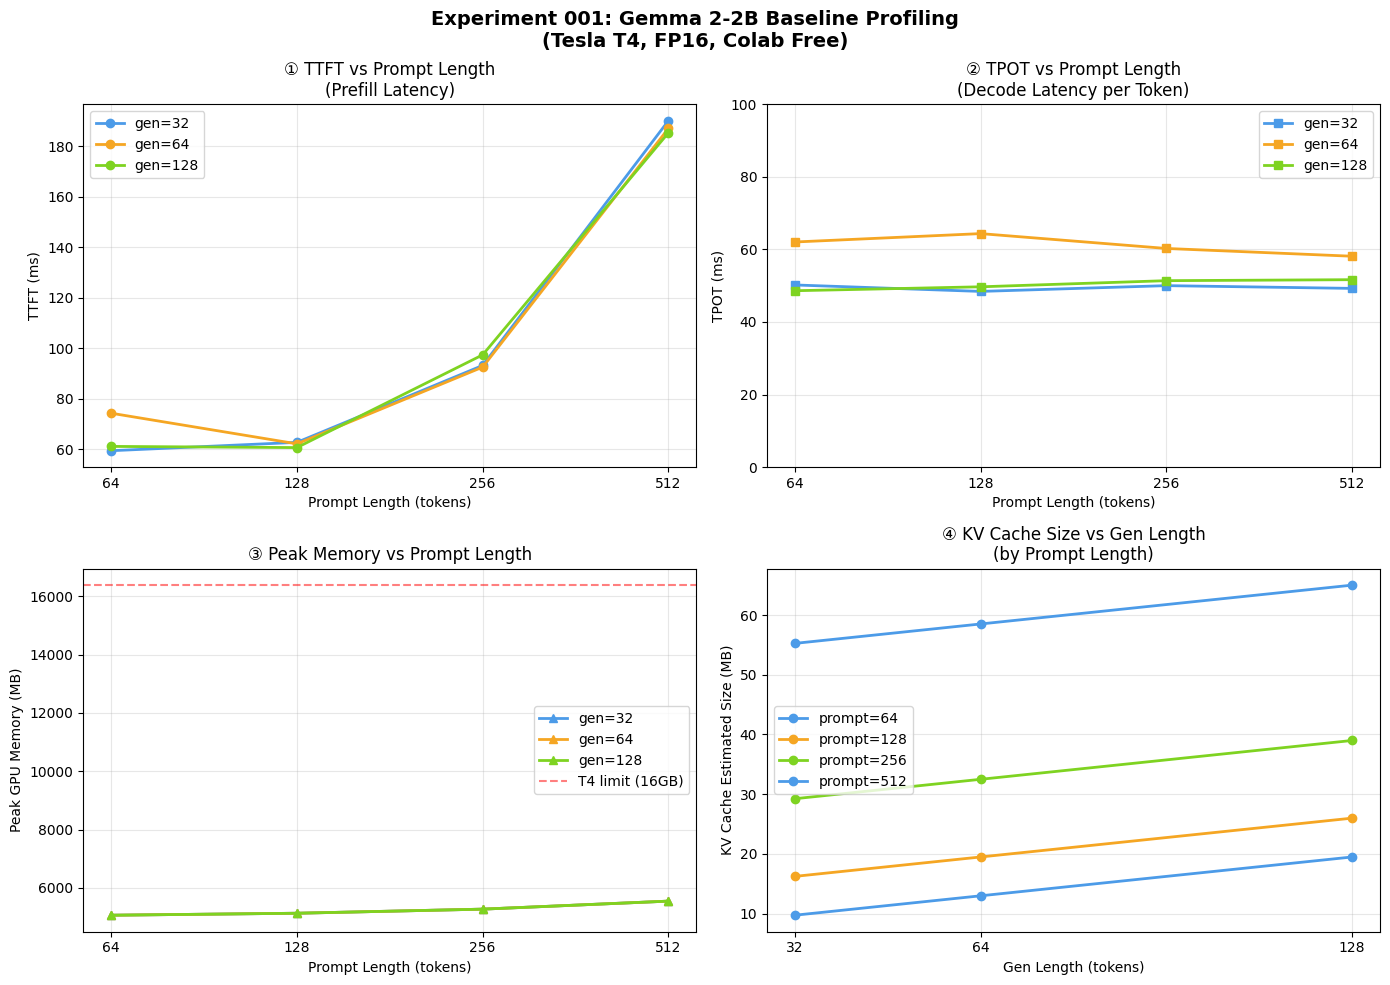

✅ 图表已保存为 exp001_profiling_results.png


In [17]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

# ── 把results列表转成DataFrame，方便按列筛选 ──
df = pd.DataFrame(results)

# 排除冷启动的第一条数据（prompt_len=64, gen_len=32的第一次运行）
# 判断标准：TTFT异常大（>500ms视为冷启动）
df_clean = df[df['ttft_ms'] < 500].copy()

# 颜色方案：不同gen_len用不同颜色区分
gen_len_list = sorted(df_clean['gen_len'].unique())   # [32, 64, 128]
colors = ['#4C9BE8', '#F5A623', '#7ED321']            # 蓝/橙/绿

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Experiment 001: Gemma 2-2B Baseline Profiling\n(Tesla T4, FP16, Colab Free)',
             fontsize=14, fontweight='bold')

# ── 图1：TTFT vs Prompt Length ────────────────────────────
# 核心问题：prefill延迟如何随输入长度增长？
# 预期：线性增长（因为prefill的计算量∝seq_len）
ax1 = axes[0, 0]
for i, gl in enumerate(gen_len_list):
    subset = df_clean[df_clean['gen_len'] == gl].sort_values('prompt_len')
    ax1.plot(subset['prompt_len'], subset['ttft_ms'],
             marker='o', color=colors[i], label=f'gen={gl}', linewidth=2)
ax1.set_xlabel('Prompt Length (tokens)')
ax1.set_ylabel('TTFT (ms)')
ax1.set_title('① TTFT vs Prompt Length\n(Prefill Latency)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xscale('log', base=2)
ax1.set_xticks([64, 128, 256, 512])
ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
# 标注：如果曲线是直线，说明prefill是O(n)，符合理论

# ── 图2：TPOT vs Prompt Length ────────────────────────────
# 核心问题：decode速度是否受prompt长度影响？
# 预期：应该相对平稳（因为每步decode只处理1个token）
# 如果随prompt增大而变慢，说明KV Cache读取开销在增加
ax2 = axes[0, 1]
for i, gl in enumerate(gen_len_list):
    subset = df_clean[df_clean['gen_len'] == gl].sort_values('prompt_len')
    ax2.plot(subset['prompt_len'], subset['tpot_ms'],
             marker='s', color=colors[i], label=f'gen={gl}', linewidth=2)
ax2.set_xlabel('Prompt Length (tokens)')
ax2.set_ylabel('TPOT (ms)')
ax2.set_title('② TPOT vs Prompt Length\n(Decode Latency per Token)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xscale('log', base=2)
ax2.set_xticks([64, 128, 256, 512])
ax2.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax2.set_ylim(0, 100)  # 固定Y轴范围，便于观察波动幅度

# ── 图3：Peak Memory vs Prompt Length ────────────────────
# 核心问题：显存主要被什么占用？
# 预期：随prompt增大而线性增长（更长的KV Cache）
# 关键观察：不同gen_len的曲线是否重合？（重合说明gen阶段追加的KV可忽略）
ax3 = axes[1, 0]
for i, gl in enumerate(gen_len_list):
    subset = df_clean[df_clean['gen_len'] == gl].sort_values('prompt_len')
    ax3.plot(subset['prompt_len'], subset['peak_mem_mb'],
             marker='^', color=colors[i], label=f'gen={gl}', linewidth=2)
# 画一条水平虚线标注T4总显存（16GB），直观显示还有多少余量
ax3.axhline(y=16*1024, color='red', linestyle='--', alpha=0.5, label='T4 limit (16GB)')
ax3.set_xlabel('Prompt Length (tokens)')
ax3.set_ylabel('Peak GPU Memory (MB)')
ax3.set_title('③ Peak Memory vs Prompt Length')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xscale('log', base=2)
ax3.set_xticks([64, 128, 256, 512])
ax3.xaxis.set_major_formatter(ticker.ScalarFormatter())

# ── 图4：KV Cache估算 vs 总序列长度 ──────────────────────
# 核心问题：KV Cache的理论大小如何增长？
# X轴用prompt+gen的总长度，更能体现KV Cache的实际规模
# 预期：严格线性（因为公式是线性的）
ax4 = axes[1, 1]
for i, pl in enumerate(sorted(df_clean['prompt_len'].unique())):
    subset = df_clean[df_clean['prompt_len'] == pl].sort_values('gen_len')
    ax4.plot(subset['gen_len'], subset['kv_est_mb'],
             marker='o', color=colors[i % len(colors)],
             label=f'prompt={pl}', linewidth=2)
ax4.set_xlabel('Gen Length (tokens)')
ax4.set_ylabel('KV Cache Estimated Size (MB)')
ax4.set_title('④ KV Cache Size vs Gen Length\n(by Prompt Length)')
ax4.set_xticks([32, 64, 128])
ax4.legend()
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('exp001_profiling_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 图表已保存为 exp001_profiling_results.png")